In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [36]:
df=pd.read_csv("Travel.csv")

In [37]:
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [38]:
df["ProductPitched"].unique()

array(['Deluxe', 'Basic', 'Standard', 'Super Deluxe', 'King'],
      dtype=object)

In [39]:
df["TypeofContact"].unique()

array(['Self Enquiry', 'Company Invited', nan], dtype=object)

In [40]:
df.isna().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [41]:
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [42]:
categorical_features = [
    "Gender",
    "Occupation",
    "MaritalStatus",
    "ProductPitched",
    "TypeofContact",
    "Designation"
]

In [43]:
numerical_features = [
    "Age",
    "CityTier",
    "DurationOfPitch",
    "NumberOfPersonVisiting",
    "NumberOfFollowups",
    "PreferredPropertyStar",
    "NumberOfTrips",
    "Passport",
    "PitchSatisfactionScore",
    "OwnCar",
    "NumberOfChildrenVisiting",
    "MonthlyIncome"
]

<Axes: >

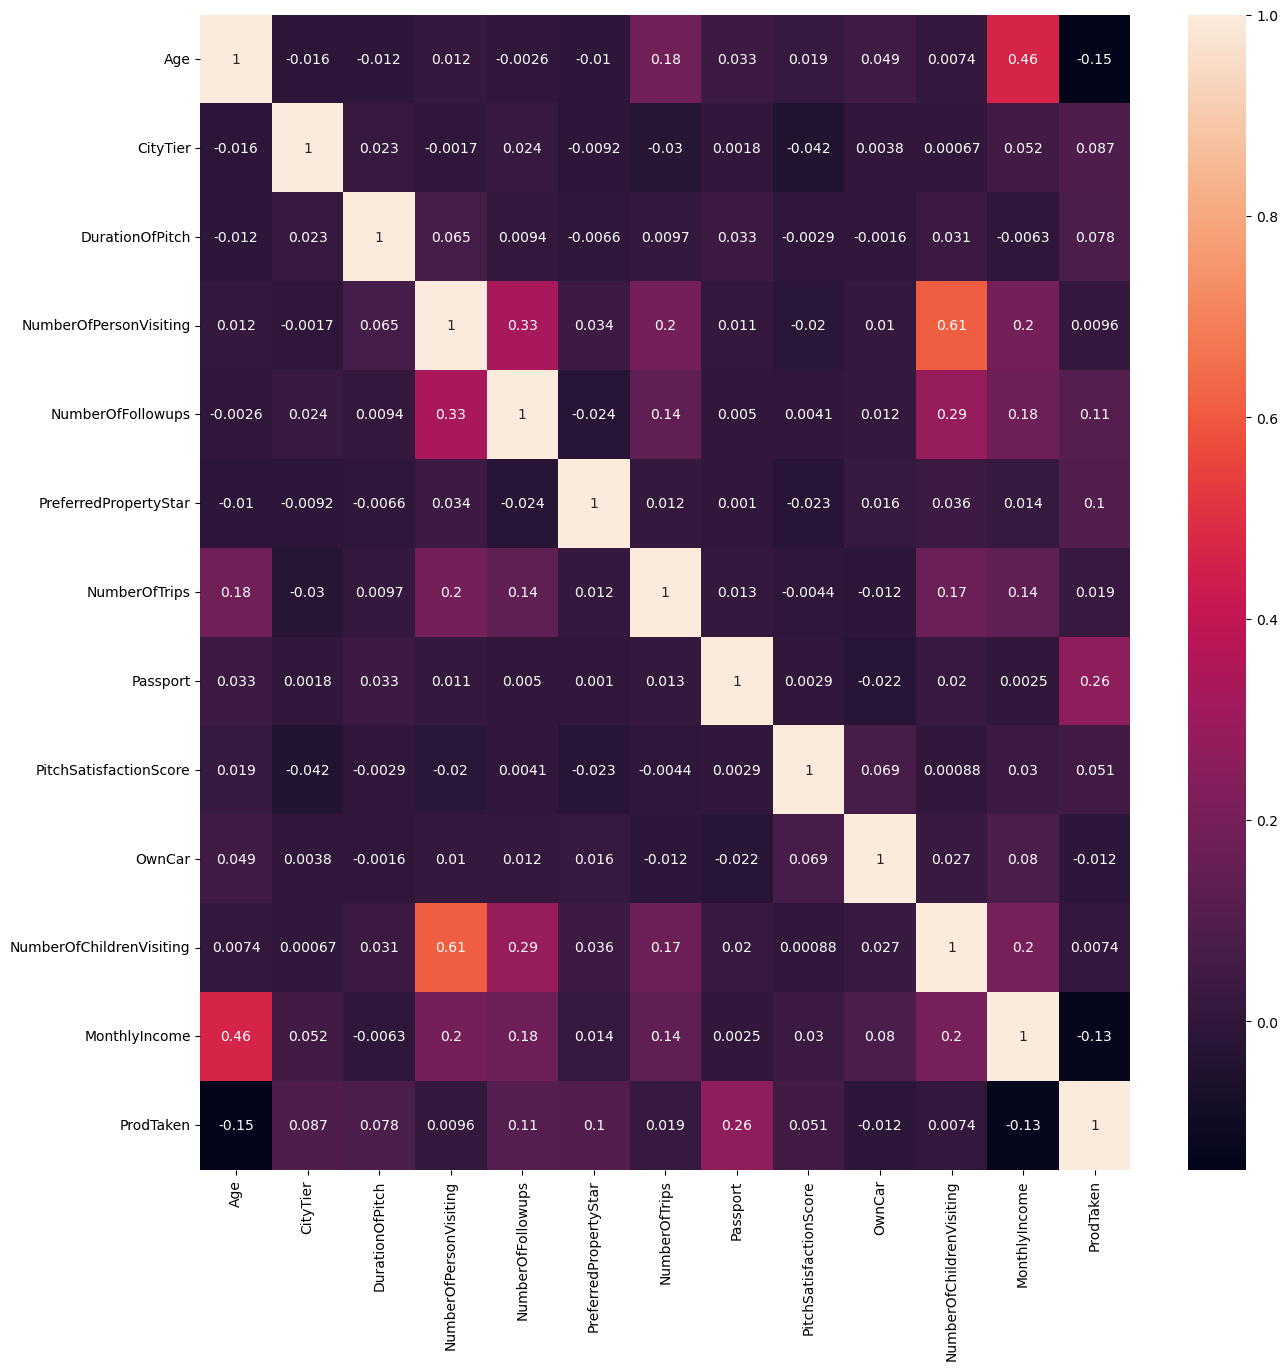

In [44]:
plt.figure(figsize=(15,15))
corr=df[numerical_features+["ProdTaken"]].corr()
sns.heatmap(corr,annot=True)

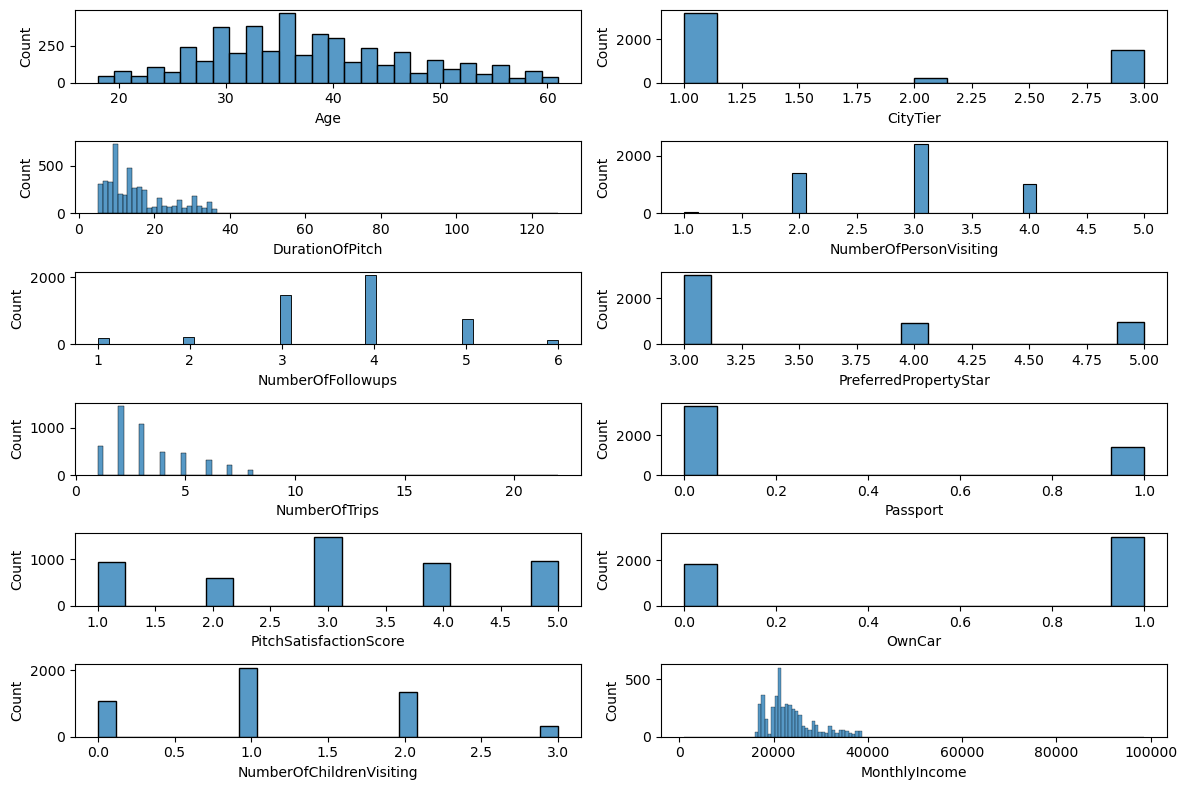

In [45]:
fig,ax=plt.subplots(6,2,figsize=(12,8))
for i,col in enumerate(numerical_features):
    sns.histplot(data=df,x=col,ax=ax[i//2,i%2])

fig.tight_layout()
plt.show()

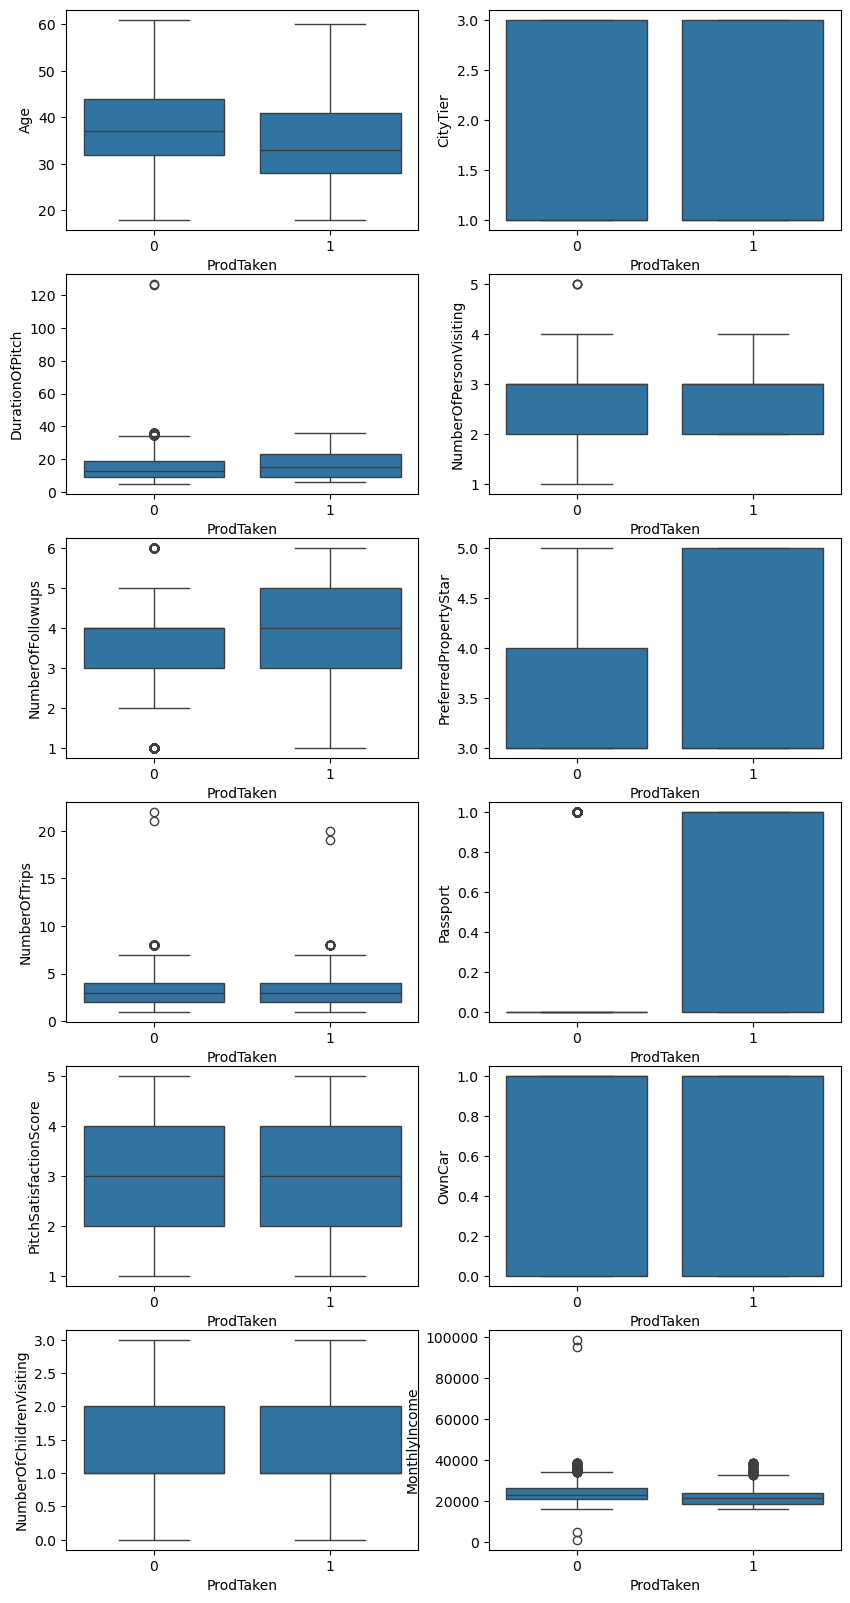

In [46]:
fig,ax=plt.subplots(6,2,figsize=(10,20))
for i,col in enumerate(numerical_features):
    sns.boxplot(data=df,x="ProdTaken",y=col,ax=ax[i//2,i%2])

In [47]:
from scipy.stats import chi2_contingency

alpha=0.05

chi2_results={}

for col in df:
    table=pd.crosstab(df[col],df["ProdTaken"])
    
    chi2_stat,p,_,_=chi2_contingency(table)

    decision="Reject Null (keep feature)" if p<alpha else "Accept Null (drop feature)"

    chi2_results[col]={
        "chi2_statistics":chi2_stat,
        "p_value":p,
        "Decision":decision
    }

In [48]:
chi=pd.DataFrame(chi2_results).T
chi=chi.sort_values(by="p_value")

In [49]:
chi

,chi2_statistics,p_value,Decision
ProdTaken,4881.457293,0.0,Reject Null (keep feature)
Passport,331.109969,0.0,Reject Null (keep feature)
ProductPitched,261.273951,0.0,Reject Null (keep feature)
Designation,261.273951,0.0,Reject Null (keep feature)
MonthlyIncome,3677.10708,0.0,Reject Null (keep feature)
MaritalStatus,194.639535,0.0,Reject Null (keep feature)
Age,306.939759,0.0,Reject Null (keep feature)
NumberOfFollowups,78.894304,0.0,Reject Null (keep feature)
PreferredPropertyStar,48.856869,0.0,Reject Null (keep feature)
CityTier,38.20259,0.0,Reject Null (keep feature)


In [50]:
df=df.drop(["Gender","OwnCar","CustomerID","NumberOfChildrenVisiting"],axis=1)

In [51]:
df["ProdTaken"].value_counts()

ProdTaken
0    3968
1     920
Name: count, dtype: int64

In [52]:
categorical_features
categorical_features.remove("Gender")

In [53]:
numerical_features.remove("OwnCar")

# numerical_features.remove("CustomerID")
numerical_features.remove("NumberOfChildrenVisiting")

In [54]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

cat_transformer=Pipeline([
    ("Imputer",SimpleImputer(strategy="most_frequent")),
    ("encoder",OneHotEncoder(handle_unknown="ignore"))
])

num_transformer=Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler())
])

transformer=ColumnTransformer([
    ("numeric",num_transformer,numerical_features),
    ("cat",cat_transformer,categorical_features)
],remainder="passthrough")

In [55]:
transformer

,transformers,"[('numeric', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [56]:
X=df.drop("ProdTaken",axis=1)
y=df["ProdTaken"]

In [57]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [58]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
pipeline=Pipeline([
    ("preprocessor",transformer),
    ("model",RandomForestClassifier())
])

pipeline.fit(X_train,y_train)

y_pred=pipeline.predict(X_test)

print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.9182156133828996
[[1305   16]
 [ 116  177]]
              precision    recall  f1-score   support

           0       0.92      0.99      0.95      1321
           1       0.92      0.60      0.73       293

    accuracy                           0.92      1614
   macro avg       0.92      0.80      0.84      1614
weighted avg       0.92      0.92      0.91      1614



In [59]:
y_test.head(20)

144     0
79      0
2098    0
4738    0
2858    1
1164    0
787     0
1504    1
287     0
4176    0
2836    0
3214    0
1971    0
3113    1
4885    1
856     0
179     0
4856    1
4092    0
4415    0
Name: ProdTaken, dtype: int64

In [60]:
y_pre=pd.Series(y_pred)
y_pre.head(20)

0     0
1     0
2     0
3     0
4     1
5     0
6     0
7     1
8     0
9     0
10    0
11    0
12    0
13    0
14    1
15    0
16    0
17    0
18    0
19    0
dtype: int64

In [61]:
model = pipeline.named_steps["model"]

feature_names = pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

importance = pd.DataFrame({

    "Feature":feature_names,

    "Importance":model.feature_importances_

})

importance.sort_values(
    "Importance",
    ascending=False
).head(20)

,Feature,Importance
9,numeric__MonthlyIncome,0.138180
0,numeric__Age,0.125409
2,numeric__DurationOfPitch,0.107974
7,numeric__Passport,0.085066
6,numeric__NumberOfTrips,0.069318
8,numeric__PitchSatisfactionScore,0.063150
4,numeric__NumberOfFollowups,0.058635
5,numeric__PreferredPropertyStar,0.046337
1,numeric__CityTier,0.040542
3,numeric__NumberOfPersonVisiting,0.031243
